# **02. SQL Analysis of clean dataset**

This notebook presents a structured analysis of the retail sales dataset using SQL queries. The analysis is organized into four sections:
1. **Revenue analysis**: examines revenue trends over time to identify seasonal patterns, and ranks products and countries by their contribution to total revenue.   

2. **Volume analysis**: mirrors the revenue analysis from a volume perspective. Since product prices vary significantly, volume and revenue rankings may diverge; this section helps clarify those differences.

3. **Returns analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.

4. **Customer analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.

In [1]:
import sys
sys.path.append('../src')
from models import SalesRecord, ReturnRecord, Invoice

import pandas as pd
import sqlite3
from sqlalchemy import create_engine

In [2]:
import matplotlib.pyplot as plt

In [19]:
df_sales = pd.read_csv("../data/sales_clean.csv")
df_returns = pd.read_csv("../data/returns_clean.csv")

In [20]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17946

## 2.1 Revenue analysis

### 2.1.1 Temporal revenue trends

#### **Revenue trend across all months and years**
To get a general overview of revenue trends, let us first visualize them across all months.

In [43]:
q_net_revenue = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """
df_net_rev = pd.read_sql(q_net_revenue,engine) # Net revenue

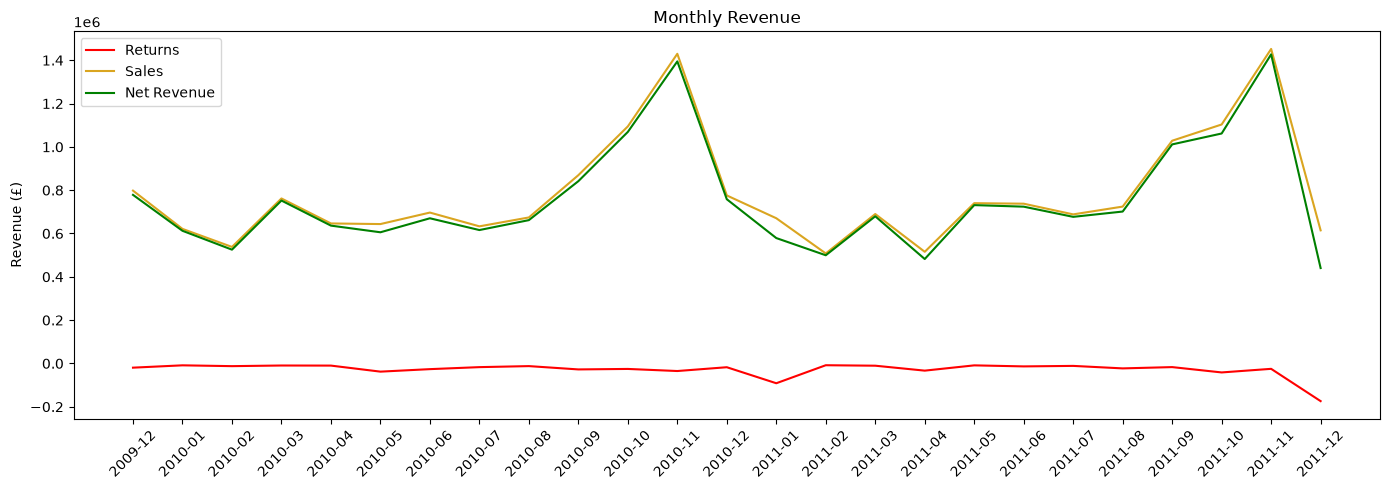

In [44]:
# To get more info, separate sales from returns
q_returns = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM returns
    GROUP BY year_month
    ORDER BY year_month
    """

q_sales = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """
df_ret = pd.read_sql(q_returns,engine) # Returns revenue
df_sal = pd.read_sql(q_sales,engine)   # Sales revenue

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_ret["year_month"], df_ret["revenue"],c="red", label="Returns")
plt.plot(df_sal["year_month"], df_sal["revenue"],c="goldenrod", label="Sales")
plt.plot(df_net_rev["year_month"], df_net_rev["revenue"],c="green", label="Net Revenue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

#### **Revenue trend per quarter**
For this step of the analysis I will leave out the 2009 year, since it only contains data for the month of December.    
Of the years 2010-2011 let us see what are the quarter trends and whether they repeat across years.

In [45]:
quarters_query = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_quarters = pd.read_sql(quarters_query,engine)
df_quarters["year_quarter"] = df_quarters["year"] + "-" + df_quarters["quarter"]

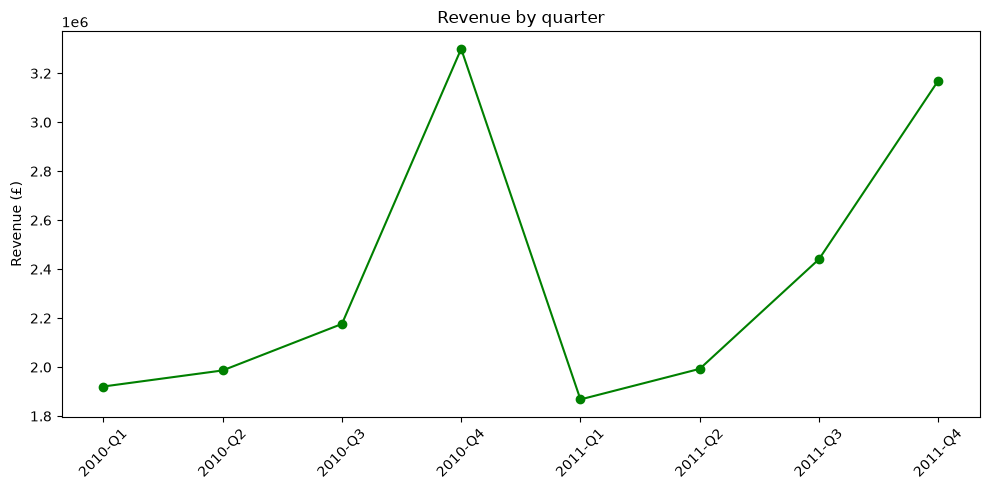

In [46]:
df_quarters
plt.figure(figsize=(10,5))
plt.plot(df_quarters["year_quarter"], df_quarters["revenue"],c="green", marker='o')
plt.xticks(rotation=45)
plt.title("Revenue by quarter")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

The trend seems to be consistent for the 4 quarters of years 2010-2011: The total revenue slowly increases from Q1 to Q3, which is followed by a steep increase in revenue in Q4.    
The total revenue then drops again by Q1.    
This behaviour may be consistent with the generally high volume of sales that most stores experience when festivities approach, which mostly occur in Q4.

### 2.1.2 Revenue per Country

In [47]:
q_country_rev = """
    SELECT SUM(Price*Quantity) AS revenue, Country
    FROM sales
    GROUP BY Country
    ORDER BY revenue DESC
    """

df_country_rev = pd.read_sql(q_country_rev, engine)

Text(0, 0.5, 'Revenue (£)')

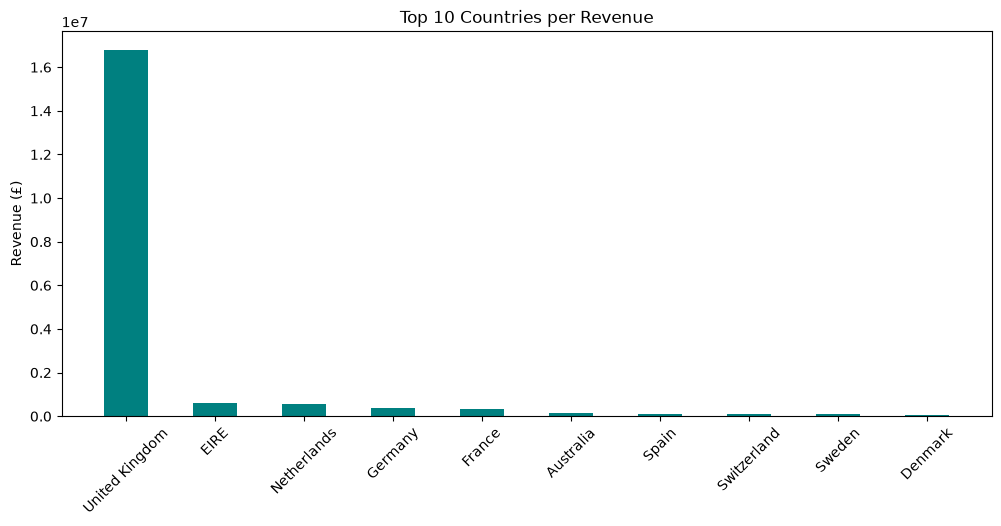

In [54]:
plt.figure(figsize=(12,5))
plt.bar(df_country_rev["Country"][:10], df_country_rev["revenue"][:10], width=0.5, color="teal")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Revenue")
plt.ylabel("Revenue (£)")


### 2.1.3 Revenue per Product

In [56]:
q_prod_rev = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_rev = pd.read_sql(q_prod_rev, engine)

Text(0, 0.5, 'Revenue (£)')

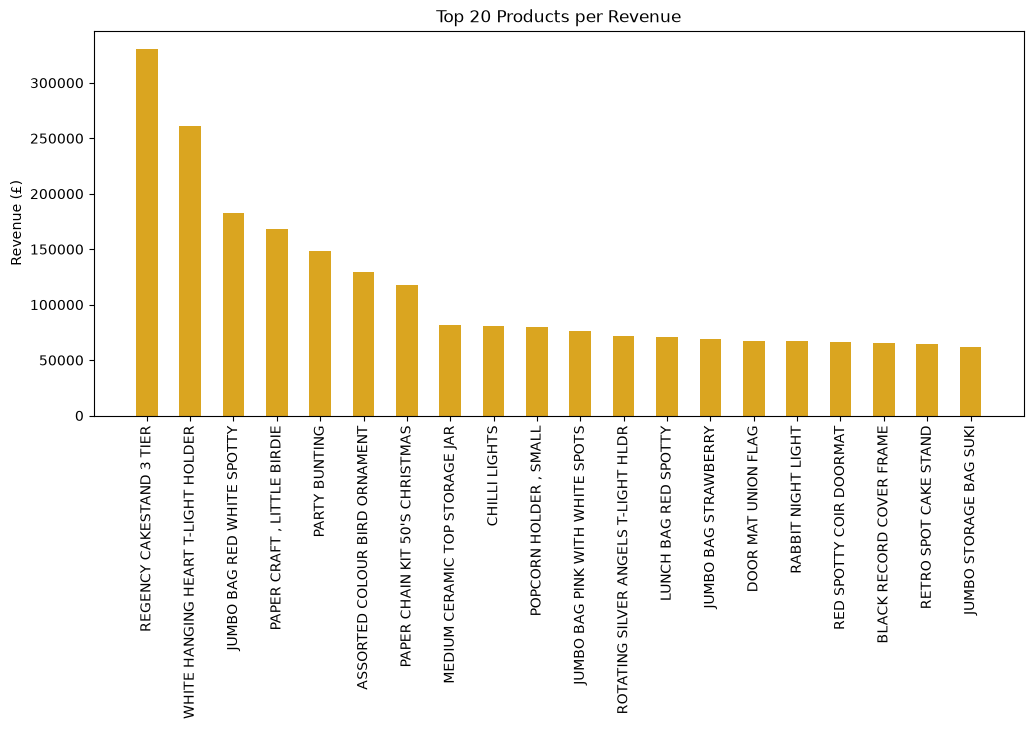

In [61]:
plt.figure(figsize=(12,5))
plt.bar(df_prod_rev["Description"][:20], df_prod_rev["revenue"][:20], width=0.5, color="goldenrod")
plt.xticks(rotation=90)
plt.title("Top 20 Products per Revenue")
plt.ylabel("Revenue (£)")


## 2.2 Volume analysis
The second step of the analysis focuses on the volume of sales, where we basically repeat the same analysis as we did for revenue, this time focusing on the number of sales.

### 2.2.1 Temporal volume trends

#### **Volume trend across all months and years**

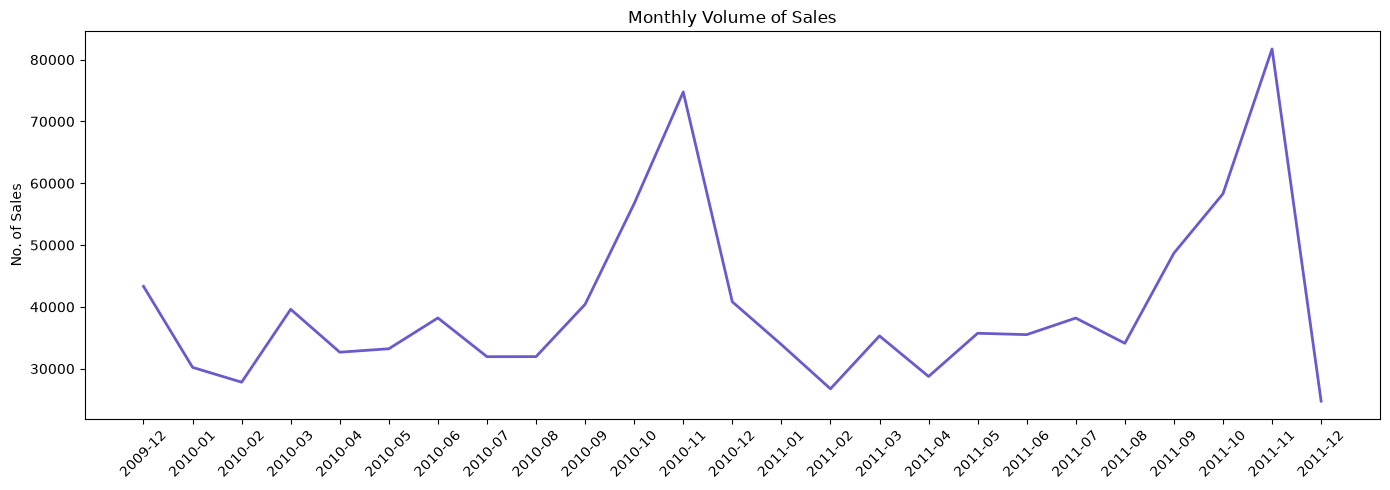

In [66]:
q_sales_vol = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, COUNT(*) AS volume
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """
df_sal_vol = pd.read_sql(q_sales_vol,engine)   # Sales revenue

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_sal_vol["year_month"], df_sal_vol["volume"],c="slateblue",linewidth=2, label="Sales")
plt.xticks(rotation=45)
plt.title("Monthly Volume of Sales")
plt.ylabel("No. of Sales")
plt.tight_layout()
plt.show()

#### **Volume of sales per quarter**

In [67]:
q_vol_quarter = """
    SELECT COUNT(*) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_sales_quart = pd.read_sql(q_vol_quarter,engine)
df_sales_quart["year_quarter"] = df_sales_quart["year"] + "-" + df_sales_quart["quarter"]

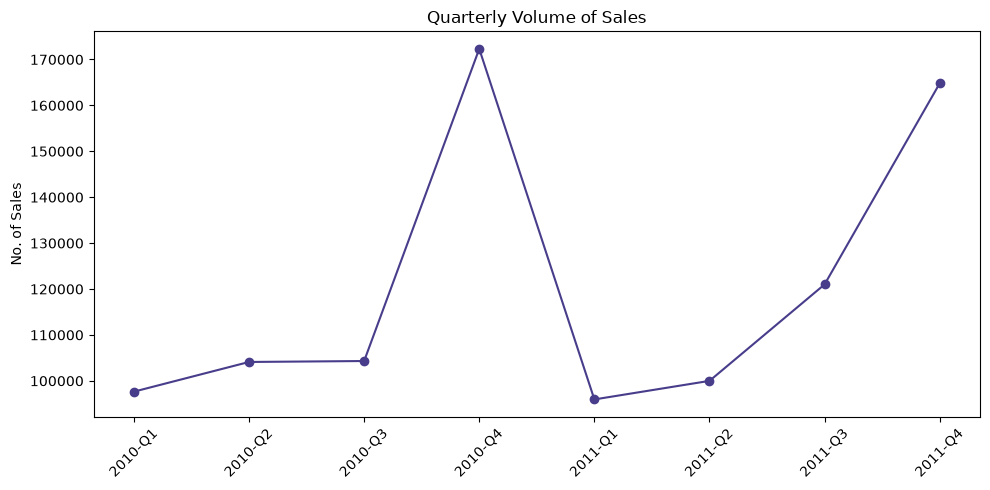

In [68]:
plt.figure(figsize=(10,5))
plt.plot(df_sales_quart["year_quarter"], df_sales_quart["volume"],c="darkslateblue", marker='o')
plt.xticks(rotation=45)
plt.title("Quarterly Volume of Sales")
plt.ylabel("No. of Sales")
plt.tight_layout()
plt.show()

Predictably, the quarterly trend for the volume of sales closely follows the one observed for the sales revenue.

### 2.2.2 Volume of sales per Country

In [69]:
q_country_vol = """
    SELECT COUNT(*) as volume, Country
    FROM sales
    GROUP BY Country
    ORDER BY volume DESC
    """

df_country_vol = pd.read_sql(q_country_vol, engine)

Text(0, 0.5, 'No. of Sales')

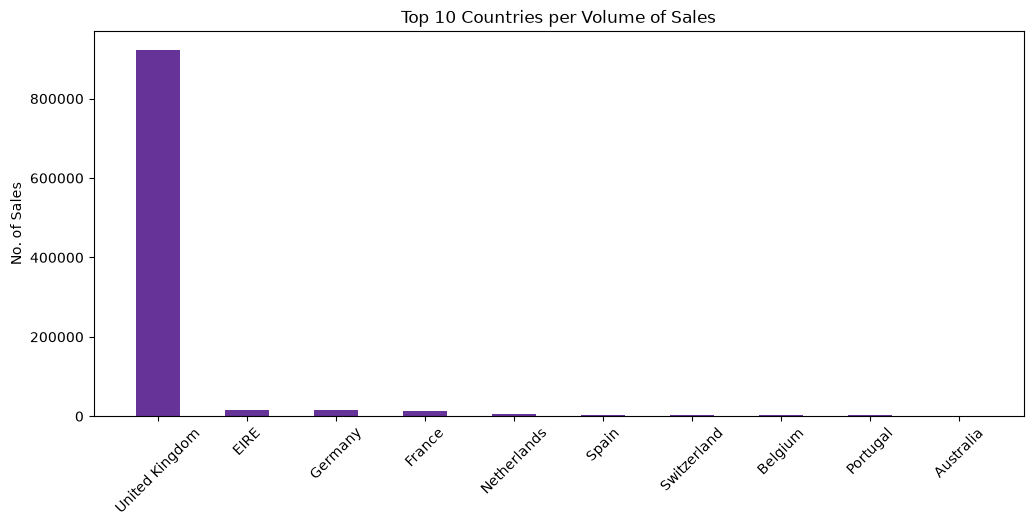

In [70]:
plt.figure(figsize=(12,5))
plt.bar(df_country_vol["Country"][:10], df_country_vol["volume"][:10], width=0.5, color="rebeccapurple")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Volume of Sales")
plt.ylabel("No. of Sales")


### 2.2.3 Volume of sales per Product

In [73]:
q_prod_vol = """
    SELECT UPPER(StockCode) as stock_code, Description, COUNT(*) as volume
    FROM sales
    GROUP BY stock_code
    ORDER BY volume DESC
    """

df_prod_vol = pd.read_sql(q_prod_vol, engine)

Text(0, 0.5, 'No. of Sales')

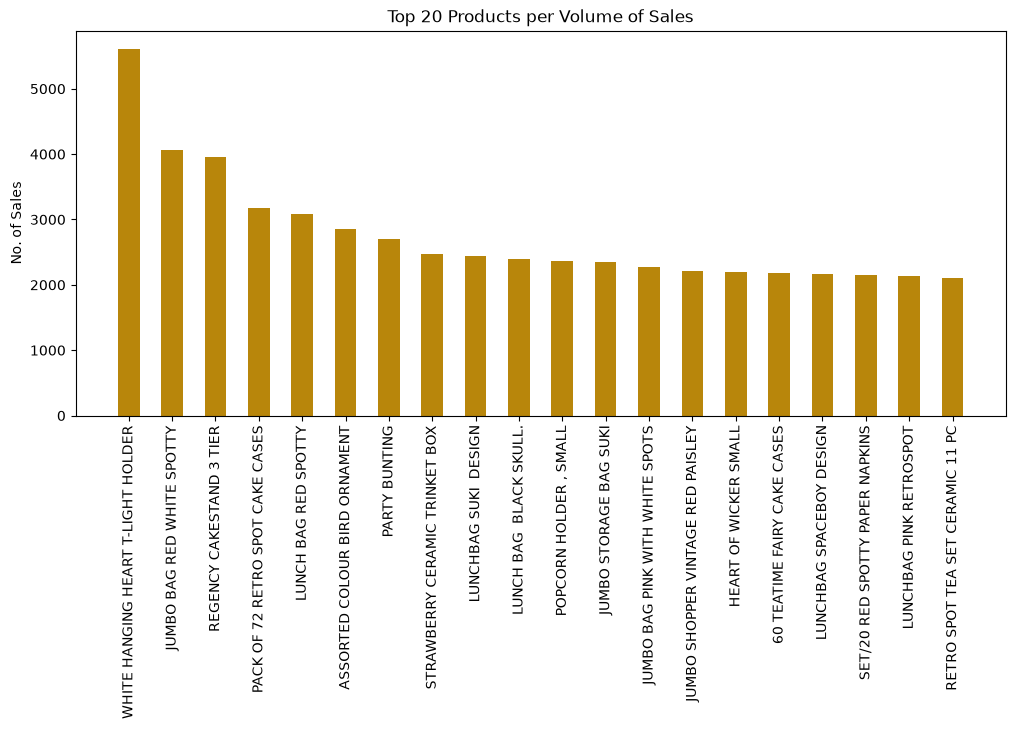

In [74]:
plt.figure(figsize=(12,5))
plt.bar(df_prod_vol["Description"][:20], df_prod_vol["volume"][:20], width=0.5, color="darkgoldenrod")
plt.xticks(rotation=90)
plt.title("Top 20 Products per Volume of Sales")
plt.ylabel("No. of Sales")


## 2.3 Returns analysis

### 2.3.1 Temporal return rate trends

#### **Return Rate across months and years**

In [78]:
# return rate
q_ret_vol = """
    SELECT COUNT(*) as volume, strftime('%Y-%m', InvoiceDate) as year_month FROM returns
    GROUP BY year_month
    ORDER BY year_month
    """

df_ret_vol = pd.read_sql(q_ret_vol,engine)

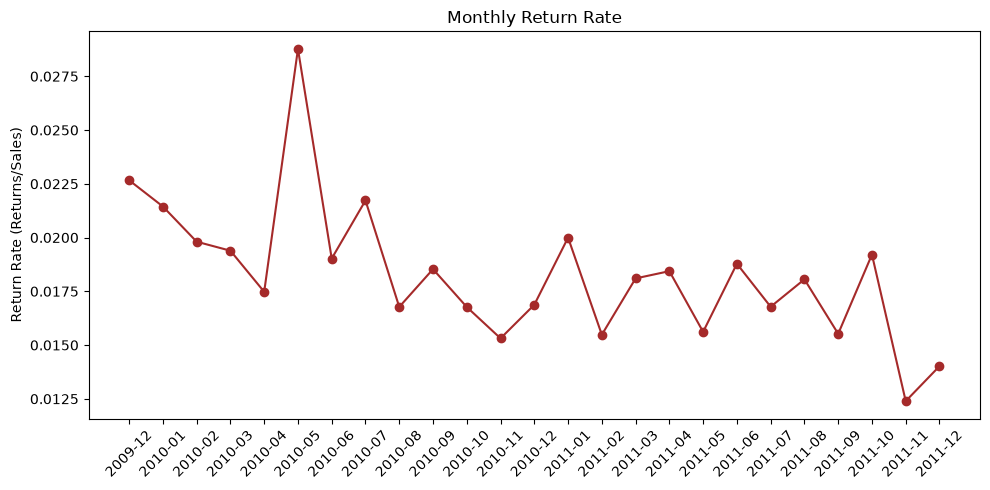

In [80]:
plt.figure(figsize=(10,5))
plt.plot(df_ret_vol["year_month"], df_ret_vol["volume"]/df_sal_vol["volume"],c="brown", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Return Rate")
plt.ylabel("Return Rate (Returns/Sales)")
plt.tight_layout()
plt.show()

#### **Return Rate across quarters**

In [ ]:
q_ret_vol_quarter = """
    SELECT COUNT(*) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM returns
    WHERE year!='2009'
    GROUP BY year, quarter
    """
df_ret_quart = pd.read_sql(q_ret_vol_quarter,engine)
df_ret_quart["year_quarter"] = df_ret_quart["year"] + "-" + df_ret_quart["quarter"]

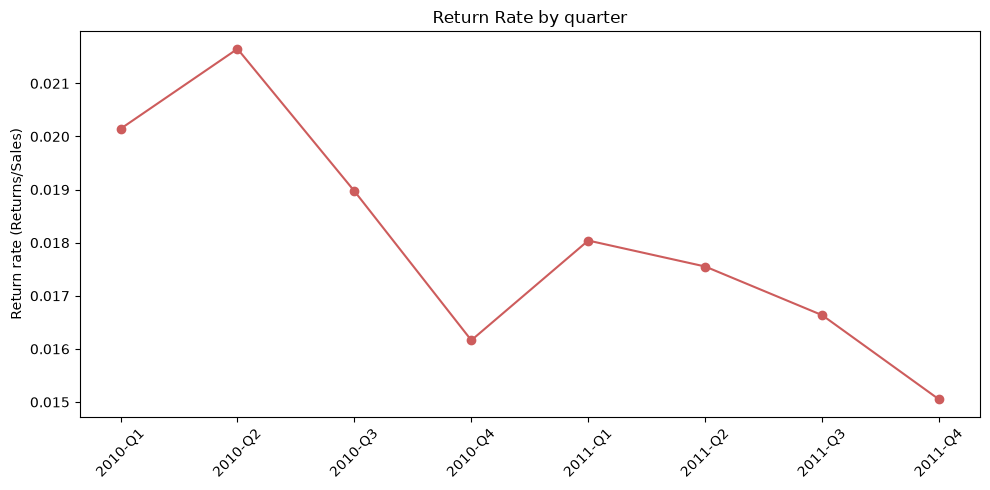

In [83]:
plt.figure(figsize=(10,5))
plt.plot(df_ret_quart["year_quarter"], df_ret_quart["volume"]/df_sales_quart["volume"],c="indianred", marker='o')
plt.xticks(rotation=45)
plt.title("Return Rate by quarter")
plt.ylabel("Return rate (Returns/Sales)")
plt.tight_layout()
plt.show()